In [21]:
import os
import pandas as pd

base_dir = r"c:\Users\ArnauCoronado\Documents_local\euromed\sxs\create\data"
edges_path = os.path.join(base_dir, "at_edges.csv")

df_numbers = pd.read_csv(edges_path)
df_strings = pd.read_csv(edges_path, dtype=str)

df = df_numbers
df['nom'] = df_strings['tag']
df['source'] = df_strings['source']
df['target'] = df_strings['target']


df.head(10)

,source,target,cabal,planta,tag,DN,OD_mm,WT_mm,d_m,area_m2,vel_ms,cabal_m3s,cabal_kgs,cabal_m3h,cabal_teo-real,vel_real,vel_teo-real,error,nom
0,8105.0,0.0,200.0,torres,8105.00,150.0,168.3,4.8,0.1587,0.019781,1,0.019781,19.780795,71.210861,-128.789139,2.808560,-1.808560,0.643946,8105.0
1,8107.0,0.0,200.0,torres,8107.00,150.0,168.3,4.8,0.1587,0.019781,1,0.019781,19.780795,71.210861,-128.789139,2.808560,-1.808560,0.643946,8107.0
2,8106.0,0.0,200.0,torres,8106.00,150.0,168.3,4.8,0.1587,0.019781,1,0.019781,19.780795,71.210861,-128.789139,2.808560,-1.808560,0.643946,8106.0
3,8108.0,0.0,200.0,torres,8108.00,150.0,168.3,4.8,0.1587,0.019781,1,0.019781,19.780795,71.210861,-128.789139,2.808560,-1.808560,0.643946,8108.0
4,8104.0,0.0,200.0,torres,8104.00,150.0,168.3,4.8,0.1587,0.019781,1,0.019781,19.780795,71.210861,-128.789139,2.808560,-1.808560,0.643946,8104.0
5,0.0,1.0,1000.0,distribució,0.01,350.0,355.0,5.0,0.3450,0.093482,1,0.093482,93.482016,336.535259,-663.464741,2.971457,-1.971457,0.663465,0.01
6,1.0,2.0,900.0,distribució,1.02,350.0,355.0,5.0,0.3450,0.093482,1,0.093482,93.482016,336.535259,-563.464741,2.674311,-1.674311,0.626072,1.02
7,2.0,3.0,890.0,distribució,2.03,350.0,355.0,5.0,0.3450,0.093482,1,0.093482,93.482016,336.535259,-553.464741,2.644597,-1.644597,0.621870,2.03
8,3.0,4.0,880.0,distribució,3.04,350.0,355.0,5.0,0.3450,0.093482,1,0.093482,93.482016,336.535259,-543.464741,2.614882,-1.614882,0.617574,3.04
9,4.0,5.0,880.0,distribució,4.05,350.0,355.0,5.0,0.3450,0.093482,1,0.093482,93.482016,336.535259,-543.464741,2.614882,-1.614882,0.617574,4.05


0    8105.0
1    8107.0
2    8106.0
3    8108.0
4    8104.0
Name: tag, dtype: str
str


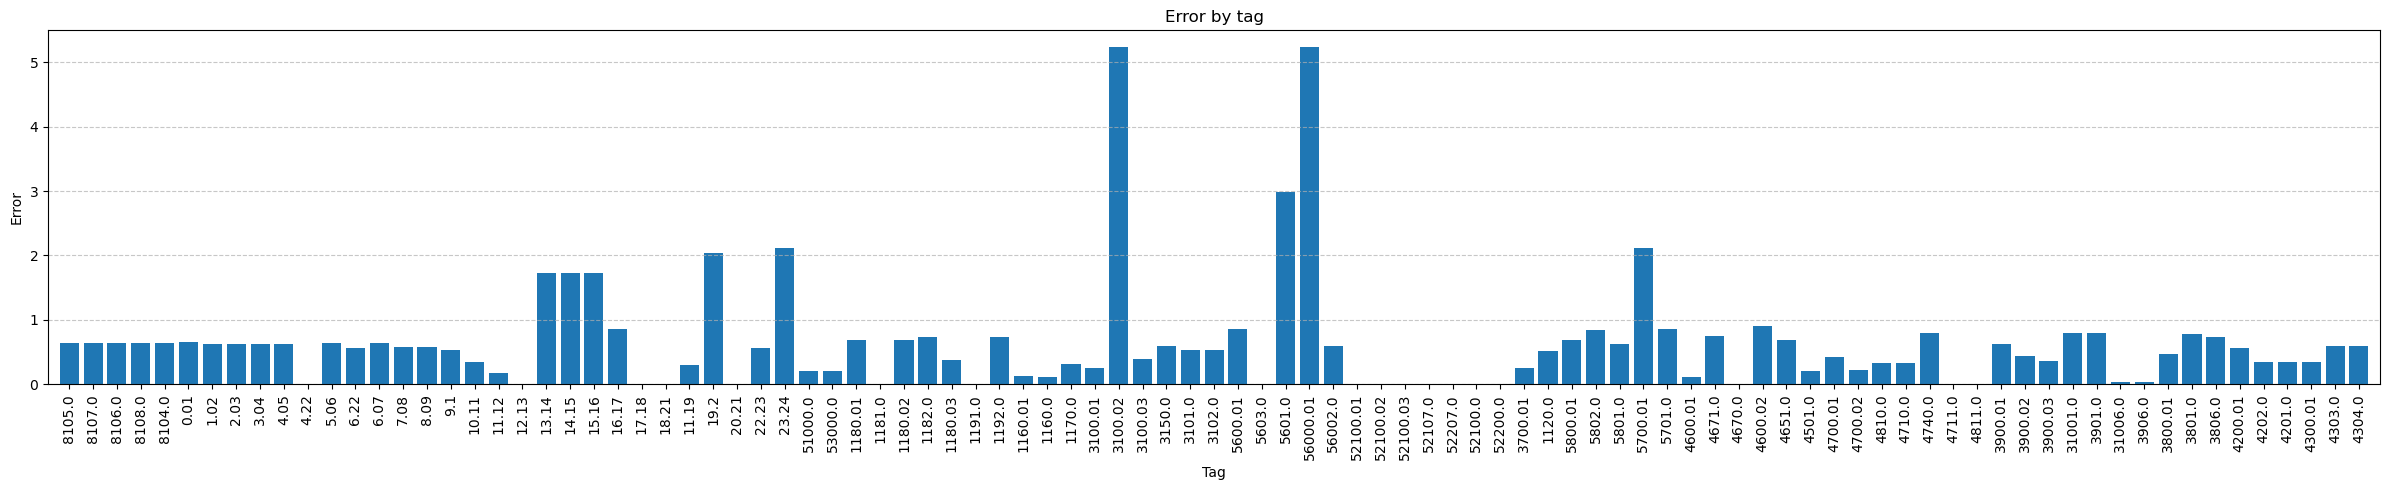

In [35]:
import os
import pandas as pd

base_dir = r"c:\Users\ArnauCoronado\Documents_local\euromed\sxs\create\data"
edges_path = os.path.join(base_dir, "at_edges.csv")

df_numbers = pd.read_csv(edges_path)
df_strings = pd.read_csv(edges_path, dtype=str)

df = df_numbers
df['nom'] = df_strings['tag']
df['source'] = df_strings['source']
df['target'] = df_strings['target']

print(df_strings['tag'].head())
print(df_strings['tag'].dtype)

import matplotlib.pyplot as plt

plt.figure(figsize=(24,5))

plt.bar(
    df["nom"],
    df["error"],
)

plt.margins(x=0.005)  # no extra space at the ends

plt.xticks(rotation=90)
plt.xlabel("Tag")
plt.ylabel("Error")
plt.title(f"Error by tag")

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


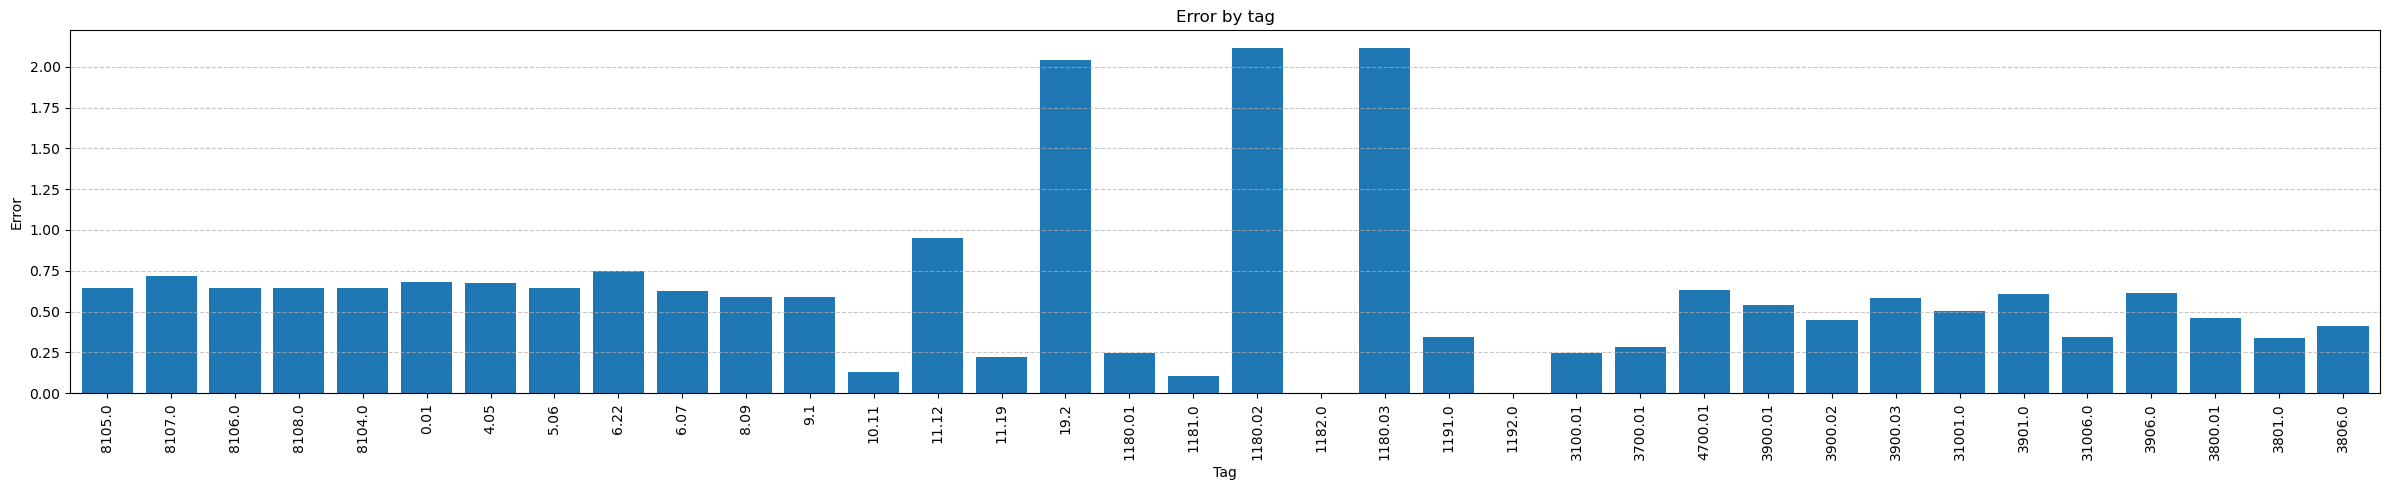

In [34]:
import os
import pandas as pd

base_dir = r"c:\Users\ArnauCoronado\Documents_local\euromed\sxs\create\data"
edges_path = os.path.join(base_dir, "at_edges_simp.csv")

df_numbers = pd.read_csv(edges_path)
df_strings = pd.read_csv(edges_path, dtype=str)

df = df_numbers
df['nom'] = df_strings['tag']
df['source'] = df_strings['source']
df['target'] = df_strings['target']


import matplotlib.pyplot as plt

plt.figure(figsize=(24,5))

plt.bar(
    df["nom"],
    df["error"],
)

plt.margins(x=0.005)  # no extra space at the ends

plt.xticks(rotation=90)
plt.xlabel("Tag")
plt.ylabel("Error")
plt.title(f"Error by tag")

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
import os
import pandas as pd
import re
from glob import glob

base_dir = r"c:\Users\ArnauCoronado\Documents_local\euromed\database_2"
edges_path = os.path.join(base_dir, "at_edges.csv")
database_path = os.path.join(base_dir, "database")
output_path = os.path.join(base_dir, "measurement_summary.csv")

# Import edges
df_edges = pd.read_csv(edges_path, dtype=str)

# Import database
all_csv_files = glob(os.path.join(database_path, "**", "*.csv"), recursive=True)

filename_regex = re.compile(r"^(\d+_\d+)[_-](.+)\.csv$", re.IGNORECASE)


for file_path in all_csv_files:
    filename = os.path.basename(file_path)

    name = os.path.splitext(filename)[0] 
    date, hour, point_id = name.split("_")

    df_csv = pd.read_csv(file_path)

    median_value = df_csv.median(numeric_only=True).median()

    print(date, hour, point_id, median_value) 

for i in df_edges["nom"]:
    print(i)



251007 0000 573-04 0.00875
251007 1003 573-04 0.00875
251008 0951 573-04 0.0101
251008 1151 573-04 0.0032
251013 0000 8100 177.3844
251013 0841 8100 177.3844
251013 0900 8100 201.76335
251013 1020 8100 203.1499
251014 0000 8105 212.4025
251014 0000 8107 190.6722
251014 0000 8109 169.707
251014 1048 8109 169.707
251014 1215 8105 212.4025
251014 1308 8105 190.6722
251015 0902 8109 148.58105
251015 0910 8109 133.4405
251015 0916 8105 207.61225000000002
251015 0917 8105 207.61225000000002
251015 0922 8105 207.00445
251015 0922 8107 207.00445
251015 0931 8106 177.72140000000002
251015 0939 8108 226.68259999999998
251015 0945 8104 204.8325
251015 1000 8109 167.1863
251015 1002 8109 167.1863
251015 1005 8109 147.37095
251015 1012 8105 197.2427
251015 1019 8105 193.32670000000002
251015 1021 8100 182.37135
251015 1021 8106 179.0317
251015 1021 8107 193.32670000000002
251015 1026 8100 182.37135
251015 1026 8106 179.0317
251015 1029 8108 227.7597
251015 1030 8108 227.7597
251015 1033 8104 182.26

In [5]:
import os
import pandas as pd
import re
from glob import glob

base_dir = r"c:\Users\ArnauCoronado\Documents_local\euromed\database_2"
edges_path = os.path.join(base_dir, "at_edges.csv")
database_path = os.path.join(base_dir, "final_database")
output_path = os.path.join(base_dir, "unique_timeseries.csv")

# Import edges
df_edges = pd.read_csv(edges_path, dtype=str)

# Import database
all_csv_files = glob(os.path.join(database_path, "**", "*.csv"), recursive=True)


print("Data", "Time", "id", "mean")
for file_path in all_csv_files:
    filename = os.path.basename(file_path)

    name = os.path.splitext(filename)[0] 
    date, time, id  = name.split("_")
    df_csv = pd.read_csv(file_path)
    median_value = df_csv.median(numeric_only=True).median()
    

    print(date, time, id, median_value)




Data Time id mean
251007 1003 573-04 0.008768696989864051
251008 0951 573-04 0.0100859306752682
251008 1151 573-04 0.0032196822110563
251013 0841 8100 177.38444366455067
251013 0900 8106 201.76333923339848
251013 1020 8106 203.14990997314453
251014 1048 8109 169.7069915771483
251014 1215 8105 212.40251312255856
251014 1308 8107 190.6721740722656
251015 0902 8109 148.5810653686524
251015 0910 8109 133.4404701232911
251015 0916 8105 207.61223373413083
251015 0922 8105 207.00449066162105
251015 0931 8106 177.72139434814454
251015 0939 8108 226.68262481689453
251015 0945 8104 204.8324661254884
251015 1002 8109 167.18626098632808
251015 1005 8109 147.37094192504898
251015 1012 8105 197.24271240234387
251015 1019 8105 193.32668380737314
251015 1026 8100 182.37133712768565
251015 1029 8108 227.7597381591798
251015 1033 8104 182.26766052246097
251027 1439 573-03 0.3885007023811332
251028 1108 573-03 0.48853266835212716
251103 1252 573-03 0.357102093100548
251104 1036 573-02 0.498184704780579
2

In [ ]:
"""
Index(['00.01', '05.06', '06.07', '06.22', '10.11', '11.12', '1120', '1160',
       '1170', '1181', '1182', '1191', '1192', '15.16', '3100.01', '3100.02',
       '3100.03', '31001', '31006', '3102', '3150', '3700.01', '3800.01',
       '3801', '3806', '3900.01', '3900.02', '3900.03', '3901', '3906',
       '4200.01', '4202', '4303', '4600.01', '4700.01', '4710', '4740', '4810',
       '52100.01', '52107', '52207', '5600.01', '5800.01', '5801', '5802',
       '8104', '8105', '8106', '8107', '8108'],
      dtype='str', name='name')
"""

In [ ]:
# records_ste.csv i plots de les mesures de vapor 
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
from glob import glob

base_dir = r"c:\Users\ArnauCoronado\Documents_local\euromed\sxs"
edges_path = os.path.join(base_dir, "create", "data", "at_edges.csv")
database_path = os.path.join(base_dir, "database", "raw_units")
output_path = os.path.join(base_dir, "database", "records_STE.csv")
plots_path = os.path.join(base_dir, "database", "plots")
os.makedirs(plots_path, exist_ok=True)
records = []

# Import edges
df_edges = pd.read_csv(edges_path, dtype=str)

# Import database
all_csv_files = glob(os.path.join(database_path, "**", "*573*.csv"), recursive=True)
#all_csv_files = [f for f in all_csv_files if "573" in os.path.basename(f)]


for file_path in all_csv_files:

    filename = os.path.basename(file_path)

    try:
        number, point_id = os.path.splitext(filename)[0].split("_")
    except ValueError:
        continue

    df_csv = pd.read_csv(file_path)

    # Try to build time axis if timestamp exists, otherwise fallback index
    if "timestamp" in df_csv.columns:
        try:
            t = pd.to_datetime(df_csv["timestamp"])
        except Exception:
            t = df_csv.index
    else:
        t = df_csv.index

    # take numeric values
    values_df = df_csv.select_dtypes(include="number")

    if values_df.empty:
        continue

    plt.figure(figsize=(10,4))

    for col in values_df.columns:
        plt.plot(t, values_df[col], label=col)

    plt.title(filename)
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid()
    plt.tight_layout()

    plot_name = os.path.splitext(filename)[0] + ".png"
    plt.savefig(os.path.join(plots_path, plot_name), dpi=150)
    plt.close()

    values = (
        df_csv
        .select_dtypes(include="number")
        .stack()
        .dropna()
    )

    if len(values) == 0:
        continue

    mode_values = values.mode()

    records.append({
        "timestamp": f"{date}_{hour}",
        "date": date,
        "hour": hour,
        "point_id": point_id,
        "count": values.count(),
        "min": values.min(),
        "max": values.max(),
        "mean": values.mean(),
        "median": values.median(),
        "mode": mode_values.iloc[0] if not mode_values.empty else None
    })

df_summary = pd.DataFrame(records)
df_summary.to_csv(output_path, index=False)


NameError: name 'hour' is not defined

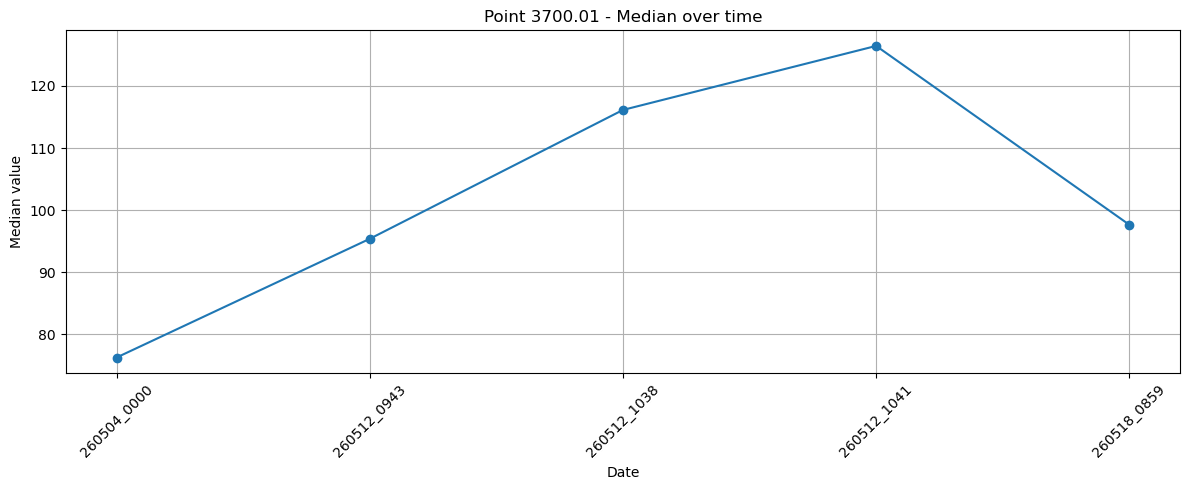

In [30]:
import os
import pandas as pd

df = pd.read_csv("records.csv")

point = "3700.01"

df_point = df[df["point_id"] == point].sort_values("timestamp")

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    df_point["timestamp"],
    df_point["median"].abs(),
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Median value")
plt.title(f"Point {point} - Median over time")

plt.grid(True)
plt.tight_layout()
plt.show()

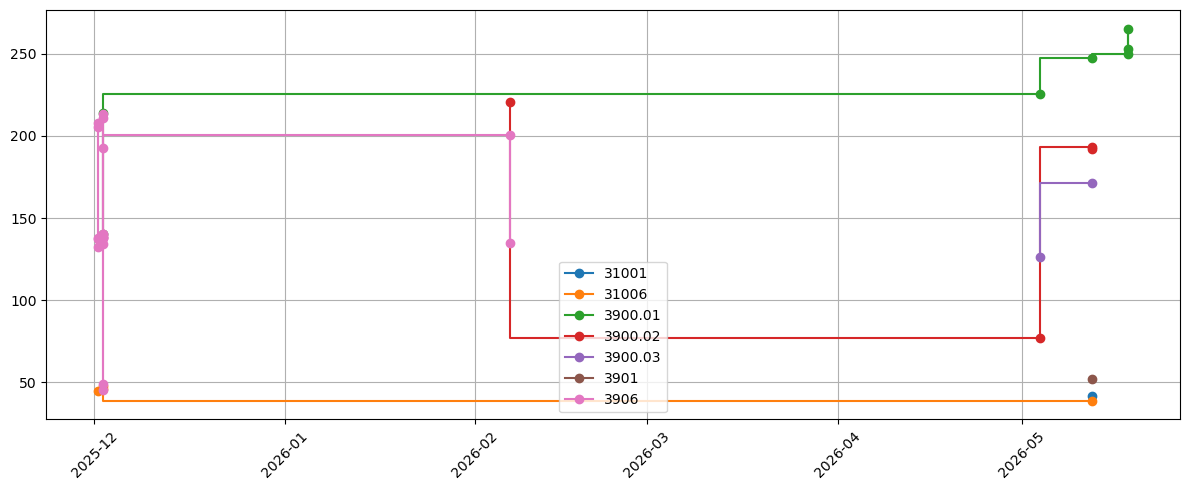

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("records.csv")

df["datetime"] = pd.to_datetime(
    df["timestamp"],
    format="%y%m%d_%H%M"
)

df = df.sort_values("datetime")
df = df.sort_values("timestamp")

points = ['3900.01', '3900.02', '3900.03', '3901', '31001', '3906', '31006']

plt.figure(figsize=(12,5))

for point, group in df[df["point_id"].isin(points)].groupby("point_id"):

    plt.step(
        group["datetime"],
        group["median"].abs(),
        marker="o",
        label=point
    )

plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

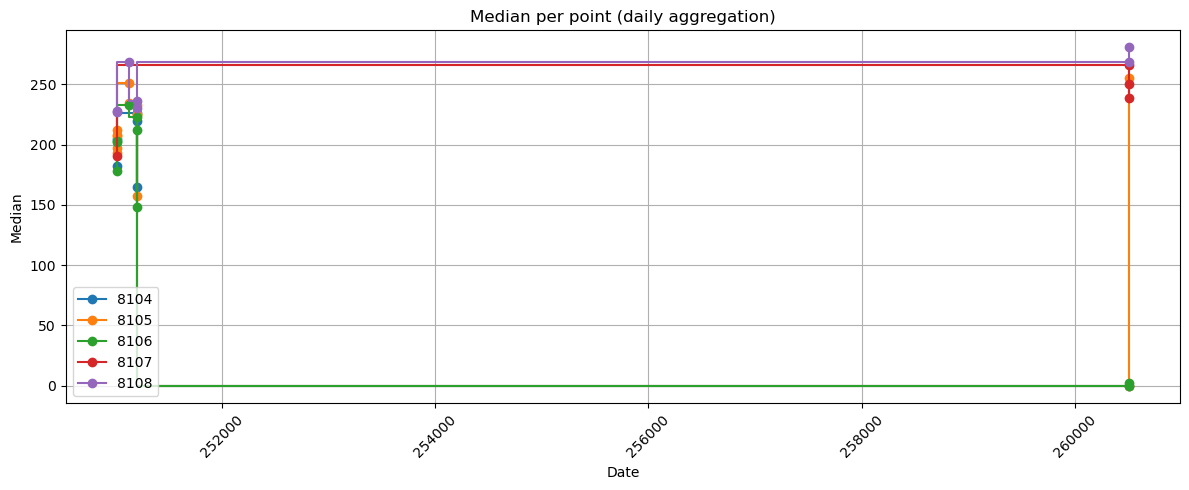

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("records.csv")

# ensure ordering (string YYYYMMDD works lexicographically)
df = df.sort_values("date")

points = ['8104', '8105', '8106', '8107', '8108']

plt.figure(figsize=(12,5))

for point in points:
    df_p = df[df["point_id"] == point].sort_values("date")

    plt.step(
        df_p["date"],
        df_p["median"],
        marker="o",
        label=point
    )

plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Median")
plt.title("Median per point (daily aggregation)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

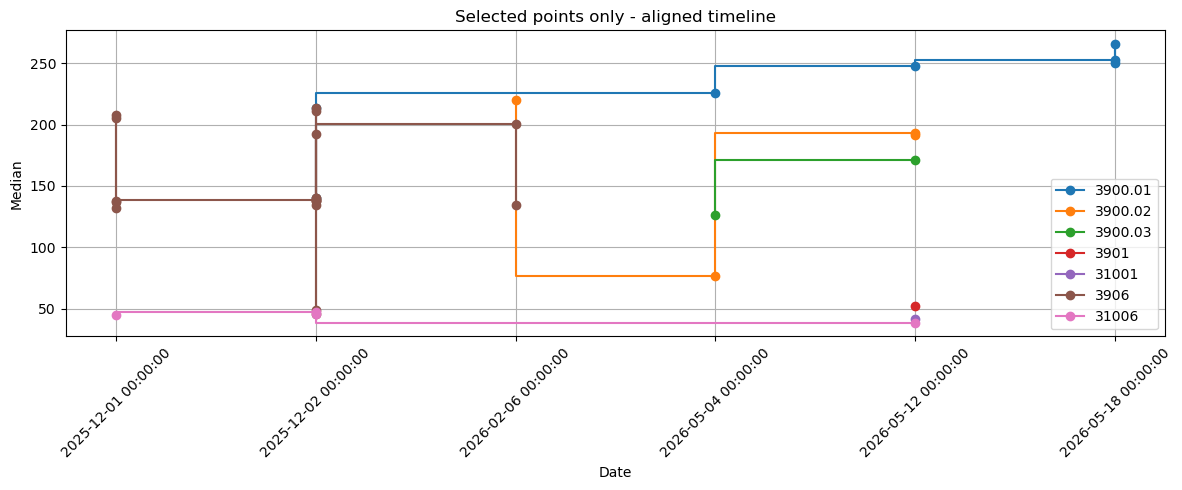

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("records.csv")

df["date"] = pd.to_datetime(df["date"], format="%y%m%d")
df = df.sort_values("date") 

bombes = ['8104', '8105', '8106', '8107', '8108']
E9001000 = ['3900.01', '3900.02', '3900.03', '3901', '31001', '3906', '31006']
selected_points = E9001000
df_sel = df[df["point_id"].isin(selected_points)]

global_dates = sorted(df_sel["date"].unique())
date_to_x = {d: i for i, d in enumerate(global_dates)}

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

for point in selected_points:
    df_p = df_sel[df_sel["point_id"] == point]

    x = df_p["date"].map(date_to_x)

    plt.step(
        x,
        df_p["median"].abs(),
        marker="o",
        label=point
    )

plt.xticks(
    range(len(global_dates)),
    global_dates,
    rotation=45
)

plt.xlabel("Date")
plt.ylabel("Median")
plt.title("Selected points only - aligned timeline")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

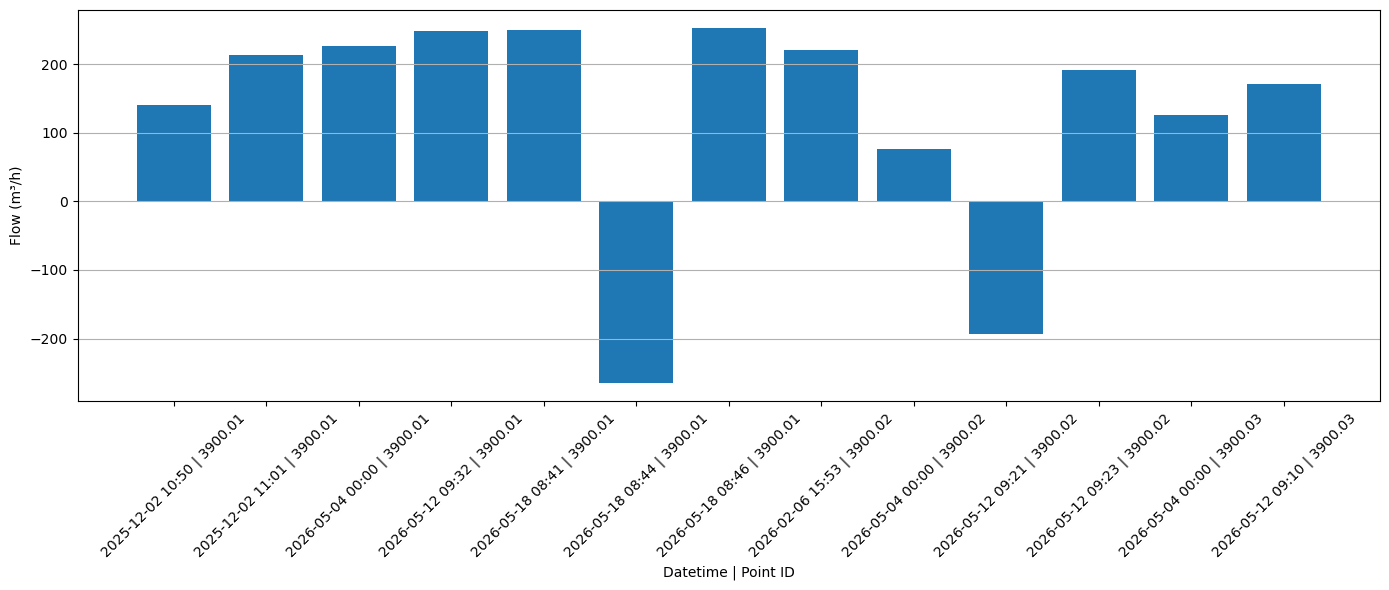

In [48]:
import pandas as pd

df = pd.read_csv("records.csv")

day = 251201
bombes = ['8104', '8105', '8106', '8107', '8108']
E9001000 = ['3900.01', '3900.02', '3900.03', '3901', '31001', '3906', '31006']
points =['3900.01', '3900.02', '3900.03']
#points = ["8104", "8105", "8106"]

df_day = df[df["point_id"].isin(points)
]

df_day = df_day.sort_values("point_id")
df_day

df["datetime"] = pd.to_datetime(df["timestamp"], format="%y%m%d_%H%M")
df_day = df[df["point_id"].isin(points)].copy()
df_day = df_day.sort_values(["point_id", "datetime"])
df_day["label"] = df_day["datetime"].dt.strftime("%Y-%m-%d %H:%M") + " | " + df_day["point_id"]

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.bar(df_day["label"], df_day["median"])

plt.xticks(rotation=45)
plt.ylabel("Flow (m³/h)")
plt.xlabel("Datetime | Point ID")
plt.grid(axis="y")
plt.tight_layout()

plt.show()


In [19]:
import pandas as pd

df = pd.read_csv("records.csv")

day = 251015
points = ["8104", "8105", "8106", "8107", "8108", "1809"]

df_day = df[
    (df["date"] == day) &
    (df["point_id"].isin(points))
]

df_day = df_day.sort_values(["point_id", "timestamp"])

df_day = df_day[["timestamp", "point_id", "median", "mean"]]

df_day

,timestamp,point_id,median,mean
15,251015_0945,8104,204.832466,204.678343
22,251015_1033,8104,182.267661,182.222149
11,251015_0916,8105,207.612234,206.844971
12,251015_0922,8105,207.004491,208.079352
18,251015_1012,8105,197.242712,196.343087
19,251015_1019,8105,193.326684,193.144969
13,251015_0931,8106,177.721394,181.028370
14,251015_0939,8108,226.682625,225.564668
21,251015_1029,8108,227.759738,225.140931


In [ ]:
import pandas as pd

df = pd.read_csv("records.csv")

day = 251209
points = ["8104", "8105", "8106", "8107", "8108", "1809"]

df_day = df[
    (df["date"] == day) &
    (df["point_id"].isin(points))
]

df_day = df_day.sort_values(["point_id", "timestamp"])

df_day = df_day[["timestamp", "count", "point_id", "median", "mean", "min", "max"]]

df_day

,timestamp,count,point_id,median,mean,min,max
124,251209_0000,57,8104,165.14600,164.584284,150.2502,174.1642
148,251209_1337,57,8104,165.14600,164.584284,150.2502,174.1642
151,251209_1348,107,8104,219.74610,225.573351,214.2227,278.5423
125,251209_0000,84,8105,157.32885,158.228424,150.0909,169.0709
146,251209_1331,84,8105,157.32885,158.228424,150.0909,169.0709
152,251209_1352,78,8105,224.80080,226.301004,221.6508,233.2564
153,251209_1356,333,8105,225.73220,224.808366,215.7998,227.6926
126,251209_0000,59,8106,148.09190,148.043019,144.9094,149.3280
147,251209_1335,59,8106,148.09190,148.043019,144.9094,149.3280
150,251209_1343,65,8106,211.68350,211.313054,207.5647,213.1789
